<a href="https://colab.research.google.com/github/Mateus-SouzaG/mvp-ml-absenteismo/blob/main/MVP_ML_Mateus_Gon%C3%A7alves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Previsão de Horas de Absenteísmo com Machine Learning

**Nome:** Mateus de Souza Gonçalves  
**Matrícula:** 4052026000051  
**Data:** 15/06/2026  
**Dataset:** Absenteeism at work  
**Fonte original dos dados:** UCI Machine Learning Repository — https://archive.ics.uci.edu/dataset/445/absenteeism+at+work  
**Tipo de problema:** Regressão supervisionada

---

# 1. Definição do problema

## 1.1 Descrição do problema

O absenteísmo no trabalho é um tema relevante para organizações, pois pode impactar o planejamento das equipes, o cumprimento de prazos e a produtividade.

Nesse contexto, métodos preditivos de análise podem contribuir para aumentar a previsibilidade sobre ocorrências de ausência, apoiando a identificação de padrões e a elaboração de estratégias preventivas ou mitigadoras.

Neste MVP, o problema abordado é a previsão da duração de ocorrências de absenteísmo, medida em horas. A proposta é utilizar dados históricos de registros de ausência no trabalho para construir modelos capazes de estimar quantas horas uma ocorrência tende a gerar.

A partir desse trabalho, busca-se elaborar uma solução capaz de apoiar análises gerenciais de RH, planejamento operacional e discussões sobre saúde ocupacional.


## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever a quantidade de horas de absenteísmo no trabalho a partir de características registradas em ocorrências de ausência.


## 1.3 Tipo de problema

O tipo de problema escolhido para este MVP é regressão supervisionada.

Primeiramente, trata-se de um problema de regressão porque a variável-alvo, Absenteeism time in hours, representa um valor numérico: a quantidade de horas de absenteísmo registrada em cada ocorrência.

Além disso, o problema também classifica-se como supervisionado, pois o dataset possui registros prévios com pareamento entre conjuntos de variáveis de entradas e valores de instâncias conhecidas da variável-alvo.


## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. A duração das ocorrências de absenteísmo não é totalmente aleatória. Espera-se que os registros históricos contenham padrões capazes de apoiar previsões sobre a quantidade de horas de ausência.
2. Variáveis relacionadas à ocorrência, como motivo da ausência, mês, dia da semana e estação do ano, podem estar associadas à duração do absenteísmo.
3. Variáveis relacionadas ao colaborador e ao vínculo de trabalho, como idade, tempo de serviço, distância entre residência e trabalho, carga média de trabalho, escolaridade e número de filhos, podem contribuir para explicar diferenças na duração das ausências.

**Critérios de sucesso:**

A métrica principal será o MAE. Sua escolha como principal deve-se a capacidade de permitir a interpretação de quanto o modelo erra, em média, ao prever a duração de uma ocorrência de absenteísmo em horas.

Além da métrica principal, também serão observadas as métricas RMSE e R², com o objetivo de complementar a avaliação dos modelos e verificar a ocorrência de erros mais elevados e o grau de explicação da variável-alvo.

O resultado mínimo esperado é que pelo menos um dos modelos testados apresente MAE inferior ao modelo baseline DummyRegressor em pelo menos 10%.

Como restrição prática, o MVP deve ser simples, reprodutível e executável através do Google Colab, priorizando modelos compatíveis com dados tabulares e de baixo custo computacional. Ademais, os dados devem ser carregados diretamente pelo GitHub, sem necessidade de upload manual.


# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção reúne as bibliotecas utilizadas, a configuração de reprodutibilidade e informações básicas do ambiente de execução.

Como o projeto utiliza modelos tradicionais de Machine Learning, aplicados a dados tabulares, não há necessidade por utilização da GPU. A carga de execução se restringirá em CPU no ambiente do Google Colab.

Para melhorar a reprodutibilidade, foi definifa uma seed fixa. essa configuração será utilizada em etapas que envolvem aleatoriedade.


In [ ]:
# === Setup básico e reprodutibilidade ===

# Bibliotecas gerais do Python
import os
import sys
import time
import random
import warnings

# Bibliotecas para manipulação de dados e visualização
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Biblioteca principal de Machine Learning
import sklearn

# Bibliotecas para divisão dos dados, validação e otimização
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from scipy.stats import randint

# Bibliotecas para pré-processamento e criação de pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modelos de regressão utilizados no MVP
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas de avaliação para problemas de regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignora avisos para manter o notebook mais limpo visualmente
warnings.filterwarnings("ignore")

# Define uma seed fixa para melhorar a reprodutibilidade dos resultados.
# A seed será usada em etapas com aleatoriedade, como amostragem,
# divisão treino/teste e modelos com componentes aleatórios.
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Informações básicas do ambiente
print("Python:", sys.version.split()[0])
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Seed:", SEED)

Python: 3.12.13
Pandas: 2.2.2
NumPy: 2.0.2
Matplotlib: 3.10.0
Scikit-learn: 1.6.1
Seed: 42


## 2.1 Dependências adicionais

Não serão necessárias dependências adicionais para esse MVP. As bibliotecas a serem utilizadas (numpy, pandas, matplotlib e sklearn) já estão disponíveis no ambiente padrão do Google Colab.

## 2.2 Funções auxiliares

As funções auxiliares abaixo serão uitilizadas para padronizar a avaliação dos modelos de regressão, organizar a comparação dos resultados e apoiar a análise dos erros.

In [ ]:
def evaluate_regression(y_true, y_pred):
    """
    Calcula métricas básicas para regressão.

    MAE: erro médio absoluto, interpretado diretamente em horas.
    RMSE: raiz do erro quadrático médio, penaliza erros grandes.
    R²: proporção da variação da variável-alvo explicada pelo modelo.
    """
    mse = mean_squared_error(y_true, y_pred)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """
    Exibe resultados dos modelos como DataFrame, ordenando pelo menor MAE.
    """
    results_df = pd.DataFrame(results_dict).T
    return results_df.sort_values(by="MAE")


def plot_actual_vs_predicted(y_true, y_pred, title="Valores reais vs. valores previstos"):
    """
    Gera um gráfico comparando as horas reais de absenteísmo
    com as horas previstas pelo modelo.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    plt.figure(figsize=(7, 5))
    plt.scatter(y_true, y_pred, alpha=0.6)

    min_value = min(y_true.min(), y_pred.min())
    max_value = max(y_true.max(), y_pred.max())

    plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

    plt.xlabel("Horas reais de absenteísmo")
    plt.ylabel("Horas previstas pelo modelo")
    plt.title(title)
    plt.show()


def plot_residuals(y_true, y_pred, title="Distribuição dos resíduos"):
    """
    Gera um histograma dos resíduos, ou seja,
    das diferenças entre valores reais e valores previstos.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    residuals = y_true - y_pred

    plt.figure(figsize=(7, 5))
    plt.hist(residuals, bins=30)

    plt.xlabel("Resíduo")
    plt.ylabel("Frequência")
    plt.title(title)
    plt.show()

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado neste MVP é o Absenteeism at work, disponibilizado originalmente pelo UCI Machine Learning Repository. A base contém registros de absenteísmo no trabalho de uma empresa de courier no Brasil, referentes ao período de julho de 2007 a julho de 2010. O conjunto de dados reúne informações sobre ocorrências de ausência, características dos colaboradores e aspectos relacionados ao contexto de trabalho.

A escolha deste dataset se justifica por sua relação direta com temas de People Analytics, Recursos Humanos, produtividade, planejamento operacional e saúde ocupacional. Como restrição, os dados representam uma empresa específica e um período histórico delimitado, portanto os resultados devem ser interpretados como uma análise exploratória e não como uma solução automaticamente generalizável para qualquer organização.

Quanto a possíveis restrições de licença, a UCI informa que o dataset está sob a licença Creative Commons Attribution 4.0 International (CC BY 4.0), permitindo compartilhamento e adaptação com o devido crédito.

Em relação a possíveis limitações por razões de privacidade e confidencialidade, é importante considerar que trata-se de uma base pública disponibilizada para fins de pesquisa e não são apresentadas informações que permitam identificar os colaboradores diretamente. Contudo, observando pelo ponto de vista ético, destaca-se que a base fornece dados potencialmente sensíveis no contexto de gestão de pessoas, como motivo de ausência, hábitos sociais, idade, características corporais e informações ligadas à saúde ocupacional. Portanto, os resultados gerados por esse MVP devem ser interpretaods de forma agregada e exploratória, sem uso para decisões individuais, automáticas ou punitivas.

**Fonte dos dados para execução no ambiente do Google Colab:** https://raw.githubusercontent.com/Mateus-SouzaG/mvp-ml-absenteismo/refs/heads/main/Absenteeism_at_work.csv

**Fonte original dos dados (somente referência):** https://archive.ics.uci.edu/dataset/445/absenteeism+at+work

## 3.2 Carga dos dados

O dataset será carregado diretamente a partir do arquivo CSV armazenado no repositório GitHub do projeto.


In [ ]:
# === Carga dos dados ===

url = "https://raw.githubusercontent.com/Mateus-SouzaG/mvp-ml-absenteismo/refs/heads/main/Absenteeism_at_work.csv"

df = pd.read_csv(url, sep=";")

print("Dataset carregado com sucesso.")
display(df.head())

Dataset carregado com sucesso.


,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,11,26,7,3,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,4
1,36,0,7,3,1,118,13,18,50,239.554,...,1,1,1,1,0,0,98,178,31,0
2,3,23,7,4,1,179,51,18,38,239.554,...,0,1,0,1,0,0,89,170,31,2
3,7,7,7,5,1,279,5,14,39,239.554,...,0,1,2,1,1,0,68,168,24,4
4,11,23,7,5,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,2


## 3.3 Visão geral do dataset

Nesta etapa, será apresentada uma visão geral da estrutura da base, incluindo quantidade de linhas e colunas, tipos de dados, valores ausentes, duplicatas, possíveis colunas que não devem entrar no modelo e identificação da variável-alvo.

Essa verificação inicial ajuda a orientar as próximas etapas de preparação dos dados e construção dos modelos.

In [ ]:
# Formato do dataset e tipos de dados

print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (740, 21)

Tipos de dados:


,tipo
ID,int64
Reason for absence,int64
Month of absence,int64
Day of the week,int64
Seasons,int64
Transportation expense,int64
Distance from Residence to Work,int64
Service time,int64
Age,int64
Work load Average/day,float64


In [ ]:
# Valores ausentes por coluna

print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
ID,0
Reason for absence,0
Month of absence,0
Day of the week,0
Seasons,0
Transportation expense,0
Distance from Residence to Work,0
Service time,0
Age,0
Work load Average/day,0


In [ ]:
# Verificação de linhas duplicadas

print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 34


In [ ]:
# Amostra aleatória da base real

display(df.sample(5, random_state=SEED))

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
120,28,27,1,6,2,225,26,9,28,308.593,...,0,1,1,0,0,2,69,169,24,1
416,33,26,4,2,3,248,25,14,47,239.409,...,0,1,2,0,0,1,86,165,32,4
334,20,10,11,4,4,260,50,11,36,284.031,...,0,1,4,1,0,0,65,168,23,8
350,1,25,12,5,4,235,11,14,37,236.629,...,0,3,1,0,0,1,88,172,29,2
412,3,28,4,4,3,179,51,18,38,239.409,...,0,1,0,1,0,0,89,170,31,4


In [ ]:
# Visão geral da variável-alvo

target = "Absenteeism time in hours"

print("Variável-alvo:", target)
print("\nResumo estatístico da variável-alvo:")

resumo_target = (
    df[target]
    .describe()
    .rename(index={
        "count": "quantidade",
        "mean": "média",
        "std": "desvio padrão",
        "min": "mínimo",
        "25%": "1º quartil",
        "50%": "mediana",
        "75%": "3º quartil",
        "max": "máximo"
    })
    .to_frame("valor")
    .round(2)
)

display(resumo_target)

Variável-alvo: Absenteeism time in hours

Resumo estatístico da variável-alvo:


,valor
quantidade,740.00
média,6.92
desvio padrão,13.33
mínimo,0.00
1º quartil,2.00
mediana,3.00
3º quartil,8.00
máximo,120.00


### Observações importantes dessa etapa:

A base possui 740 registros e 21 colunas. As variáveis foram carregadas majoritariamente como valores inteiros, com exceção da coluna Work load Average/day, carregada como valor decimal.

Não foram identificados valores ausentes nas colunas do dataset. Foram encontradas 34 linhas duplicadas, mas elas não serão removidas automaticamente nesta etapa, pois podem representar ocorrências distintas de absenteísmo com os mesmos atributos registrados.

A coluna ID representa a identificação do colaborador e não será utilizada diretamente como variável explicativa do modelo, para evitar que o algoritmo aprenda padrões associados a indivíduos específicos em vez de padrões gerais das ocorrências.

A variável-alvo do MVP é Absenteeism time in hours, que representa a quantidade de horas de absenteísmo registrada em cada ocorrência.

A análise inicial da variável-alvo mostra que a média de absenteísmo é de aproximadamente 6,92 horas, enquanto a mediana é de 3 horas. Isso indica que parte relevante das ocorrências possui curta duração, mas há registros com valores mais elevados, chegando ao máximo de 120 horas. Essa diferença entre média e mediana sugere a presença de ocorrências mais longas que podem influenciar a modelagem.

## 3.4 Dicionário de dados

A tabela abaixo apresenta os atributos do dataset, sua descrição, uso previsto no modelo e observações relevantes para a modelagem.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| ID                              | Identificador numérico | Identificador numérico do colaborador no dataset                     | Não                   | Será removido das variáveis explicativas para evitar aprendizado associado a colaboradores específicos |
| Reason for absence              | Categórica             | Motivo da ausência                                          | Sim                   | Apesar de estar em formato numérico, representa categorias de motivos de ausência                               |
| Month of absence                | Categórica             | Mês da ocorrência de ausência                               | Sim                   | Representa o mês em que a ausência foi registrada                                                   |
| Day of the week                 | Categórica             | Dia da semana da ocorrência                                 | Sim                   | Representa o dia da semana em que a ausência foi registrada                                         |
| Seasons                         | Categórica             | Estação do ano associada à ocorrência                       | Sim                   | Representa informação temporal do registro                                                          |
| Transportation expense          | Numérica               | Despesa de transporte do colaborador                        | Sim                   | Variável relacionada ao contexto do colaborador                                                     |
| Distance from Residence to Work | Numérica               | Distância entre residência e trabalho                       | Sim                   | Variável relacionada ao deslocamento do colaborador                                                 |
| Service time                    | Numérica               | Tempo de serviço do colaborador                             | Sim                   | Variável relacionada ao vínculo de trabalho                                                         |
| Age                             | Numérica               | Idade do colaborador                                        | Sim                   | Variável demográfica                                                                                |
| Work load Average/day           | Numérica               | Carga média de trabalho por dia                             | Sim                   | Variável relacionada ao contexto operacional                                                        |
| Hit target                      | Numérica               | Percentual de atingimento de meta                           | Sim                   | Variável relacionada ao contexto de trabalho                                                        |
| Disciplinary failure            | Binária                | Indica se houve falha disciplinar                           | Sim                   | Variável com valores 0 e 1                                                                          |
| Education                       | Categórica             | Escolaridade do colaborador                                 | Sim                   | Representada por códigos numéricos no dataset                                                       |
| Son                             | Numérica               | Número de filhos do colaborador                             | Sim                   | Variável de contagem                                                                                |
| Social drinker                  | Binária                | Indica consumo social de bebida alcoólica                   | Sim                   | Variável com valores 0 e 1                                                                          |
| Social smoker                   | Binária                | Indica tabagismo social                                     | Sim                   | Variável com valores 0 e 1                                                                          |
| Pet                             | Numérica               | Número de animais de estimação                              | Sim                   | Variável de contagem                                                                                |
| Weight                          | Numérica               | Peso do colaborador                                         | Sim                   | Variável corporal, devendo ser interpretada com cautela                                             |
| Height                          | Numérica               | Altura do colaborador                                       | Sim                   | Variável corporal, devendo ser interpretada com cautela                                             |
| Body mass index                 | Numérica               | Índice de massa corporal do colaborador                     | Sim                   | Variável corporal potencialmente sensível                                                           |
| Absenteeism time in hours       | Alvo numérico          | Quantidade de horas de absenteísmo registrada na ocorrência | Alvo                  | Variável-alvo do problema de regressão                                                              |



# 4. Análise exploratória dos dados
A análise exploratória tem como objetivo compreender melhor a estrutura dos dados antes da etapa de modelagem.

Nesta seção, serão analisadas a distribuição da variável-alvo, algumas variáveis explicativas relevantes e possíveis padrões associados à duração das ocorrências de absenteísmo.

Essa etapa também ajudará a identificar padrões, valores extremos e características dos dados que possam influenciar as decisões de pré-processamento e a escolha dos modelos de Machine Learning.


In [ ]:
# Configuração da análise exploratória

TARGET = "Absenteeism time in hours"
PROBLEM_TYPE = "regressão"

print("Variável-alvo:", TARGET)
print("Tipo de problema:", PROBLEM_TYPE)

if TARGET is not None and TARGET in df.columns:
    print("\nResumo estatístico da variável-alvo:")

    resumo_target = (
        df[TARGET]
        .describe()
        .rename(index={
            "count": "quantidade",
            "mean": "média",
            "std": "desvio padrão",
            "min": "mínimo",
            "25%": "1º quartil",
            "50%": "mediana",
            "75%": "3º quartil",
            "max": "máximo"
        })
        .to_frame("valor")
        .round(2)
    )

    display(resumo_target)

Variável-alvo: Absenteeism time in hours
Tipo de problema: regressão

Resumo estatístico da variável-alvo:


,valor
quantidade,740.00
média,6.92
desvio padrão,13.33
mínimo,0.00
1º quartil,2.00
mediana,3.00
3º quartil,8.00
máximo,120.00


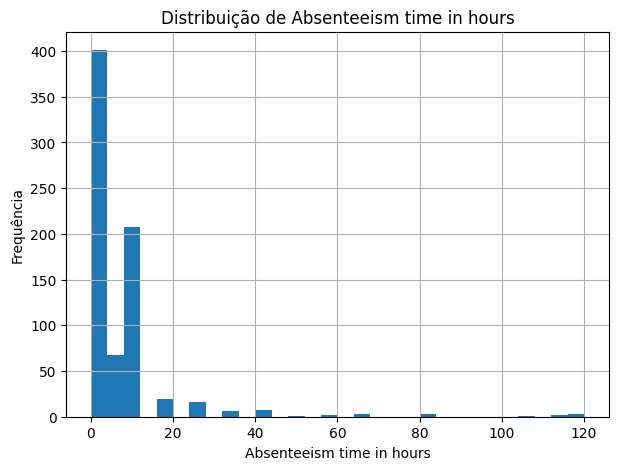

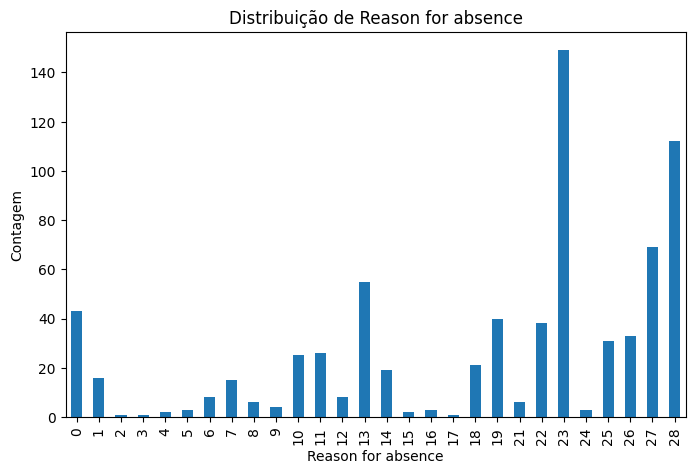

In [ ]:
# Visualizações simples da análise exploratória

numeric_col = TARGET
categorical_col = "Reason for absence"

plt.figure(figsize=(7, 5))
df[numeric_col].hist(bins=30)
plt.title(f"Distribuição de {numeric_col}")
plt.xlabel(numeric_col)
plt.ylabel("Frequência")
plt.show()

plt.figure(figsize=(8, 5))
df[categorical_col].value_counts().sort_index().plot(kind="bar")
plt.title(f"Distribuição de {categorical_col}")
plt.xlabel(categorical_col)
plt.ylabel("Contagem")
plt.show()


**Legenda da variável Reason for absence:**

A variável Reason for absence representa o motivo da ausência. Os códigos de 1 a 21 seguem categorias do CID/ICD (Classificação Internacional de Doenças), enquanto os códigos de 22 a 28 representam categorias sem CID. O código 0 aparece na base, mas não possui descrição explícita na documentação consultada, sendo tratado neste MVP como "não informado/sem classificação". As descrições foram obtidas a partir do arquivo "Attribute Information.docx" disponibilizado junto ao dataset original no UCI Machine Learning Repository, com tradução própria para português.

| Código | Descrição |
|---|---|
| 0 | Não informado / sem classificação |
| 1 | Doenças infecciosas e parasitárias |
| 2 | Neoplasias |
| 3 | Doenças do sangue e órgãos hematopoiéticos |
| 4 | Doenças endócrinas, nutricionais e metabólicas |
| 5 | Transtornos mentais e comportamentais |
| 6 | Doenças do sistema nervoso |
| 7 | Doenças dos olhos e anexos |
| 8 | Doenças do ouvido e da apófise mastoide |
| 9 | Doenças do aparelho circulatório |
| 10 | Doenças do aparelho respiratório |
| 11 | Doenças do aparelho digestivo |
| 12 | Doenças da pele e do tecido subcutâneo |
| 13 | Doenças do sistema osteomuscular e tecido conjuntivo |
| 14 | Doenças do aparelho geniturinário |
| 15 | Gravidez, parto e puerpério |
| 16 | Afecções originadas no período perinatal |
| 17 | Malformações congênitas e anomalias cromossômicas |
| 18 | Sintomas, sinais e achados clínicos/laboratoriais não classificados em outra parte |
| 19 | Lesões, envenenamentos e outras consequências de causas externas |
| 20 | Causas externas de morbidade e mortalidade |
| 21 | Fatores que influenciam o estado de saúde e contato com serviços de saúde |
| 22 | Acompanhamento de paciente |
| 23 | Consulta médica |
| 24 | Doação de sangue |
| 25 | Exame laboratorial |
| 26 | Ausência injustificada |
| 27 | Fisioterapia |
| 28 | Consulta odontológica |

,Reason for absence,contagem,media_horas,mediana_horas,maximo_horas
0,9,4,42.00,24.0,112
1,2,1,24.00,24.0,24
2,12,8,23.38,10.0,112
3,6,8,21.38,8.0,120
4,19,40,18.23,8.0,104
5,13,55,15.31,8.0,120
6,11,26,11.42,8.0,120
7,1,16,11.38,8.0,64
8,10,25,11.04,8.0,48
9,18,21,10.33,8.0,80


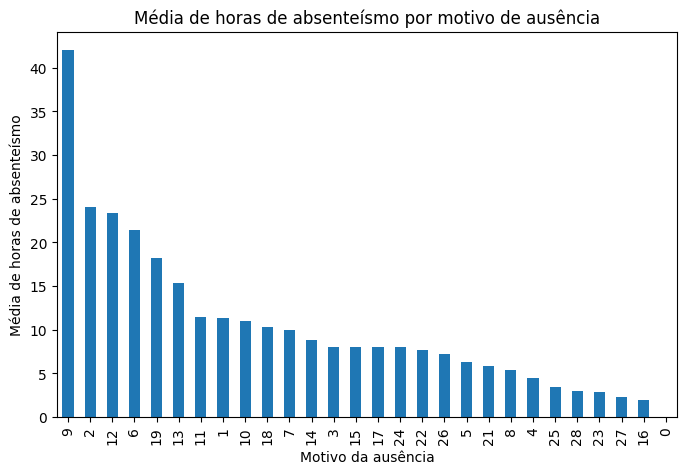

In [ ]:
# Relação entre motivo da ausência e horas de absenteísmo

reason_target = (
    df.groupby("Reason for absence")[TARGET]
    .agg(
        contagem="count",
        media_horas="mean",
        mediana_horas="median",
        maximo_horas="max"
    )
    .reset_index()
    .sort_values(by="media_horas", ascending=False)
    .reset_index(drop=True)
)

reason_target["media_horas"] = reason_target["media_horas"].round(2)

display(reason_target)

reason_target.plot(
    x="Reason for absence",
    y="media_horas",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Média de horas de absenteísmo por motivo de ausência")
plt.xlabel("Motivo da ausência")
plt.ylabel("Média de horas de absenteísmo")
plt.show()

## 4.1 Síntese da análise exploratória

A análise exploratória mostrou que a variável-alvo Absenteeism time in hours apresenta forte concentração em valores baixos, indicando que a maior parte das ocorrências de absenteísmo possui curta duração. Ao mesmo tempo, existem registros com valores mais elevados, chegando a 120 horas, o que sugere a presença de valores extremos e uma distribuição assimétrica.

Não foram identificados valores ausentes no dataset, o que reduz a necessidade de tratamentos relacionados à imputação de dados. Também foi observado que algumas variáveis possuem escalas diferentes, como idade, distância entre residência e trabalho, carga média de trabalho e horas de absenteísmo, o que deverá ser considerado na etapa de pré-processamento, especialmente para modelos sensíveis à escala dos dados.

A variável Reason for absence apresentou distribuição desigual entre os códigos de motivo de ausência. Alguns motivos aparecem com frequência maior na base, como os códigos 23, 28 e 27. Como essa variável está codificada numericamente, mas representa categorias de motivos, ela deverá ser tratada como variável categórica na etapa de modelagem.

A análise da média de horas de absenteísmo por motivo de ausência indicou que alguns códigos estão associados a ausências mais longas. No entanto, parte dos códigos com maiores médias possui baixa quantidade de registros, o que exige cautela na interpretação. Ainda assim, o resultado reforça a hipótese inicial de que características da ocorrência, como o motivo da ausência, podem contribuir para explicar variações na duração do absenteísmo.

# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, serão definidas as variáveis explicativas, a variável-alvo e a estratégia de divisão entre treino e teste.

A variável-alvo do MVP é Absenteeism time in hours. A coluna ID será removida das variáveis explicativas por representar a identificação do colaborador no dataset, evitando que o modelo aprenda padrões associados a indivíduos específicos.

Como este MVP trata de um problema de regressão, a divisão entre treino e teste será feita por holdout, com 80% dos dados para treino e 20% para teste. A divisão será feita antes das etapas de pré-processamento, para evitar vazamento de informações do conjunto de teste.

In [ ]:
# === Configuração do problema ===

TARGET = "Absenteeism time in hours"
PROBLEM_TYPE = "regressao"

ID_COLUMNS = ["ID"]
DROP_COLUMNS = []

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS + [TARGET])

features = [col for col in df.columns if col not in columns_to_exclude]

print("Tipo de problema:", PROBLEM_TYPE)
print("Variável-alvo:", TARGET)
print("Colunas removidas:", ID_COLUMNS + DROP_COLUMNS)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: regressao
Variável-alvo: Absenteeism time in hours
Colunas removidas: ['ID']
Número de features: 19
Features: ['Reason for absence', 'Month of absence', 'Day of the week', 'Seasons', 'Transportation expense', 'Distance from Residence to Work', 'Service time', 'Age', 'Work load Average/day ', 'Hit target', 'Disciplinary failure', 'Education', 'Son', 'Social drinker', 'Social smoker', 'Pet', 'Weight', 'Height', 'Body mass index']


In [ ]:
# === Divisão dos dados ===

X = df[features].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Treino: (592, 19) | Teste: (148, 19)


## 5.1 Justificativa da divisão

A divisão entre treino e teste foi realizada por holdout, utilizando 80% dos registros para treino e 20% para teste. Essa proporção foi escolhida por ser adequada ao tamanho da base, que possui 740 registros, permitindo reservar uma parte dos dados para avaliação final sem reduzir excessivamente o conjunto utilizado para treinamento.

Como este MVP trata de um problema de regressão, não foi utilizada estratificação por classes. A variável-alvo representa a quantidade de horas de absenteísmo, ou seja, um valor numérico, e não uma categoria.

A divisão temporal também não foi adotada, pois o objetivo do MVP não é realizar forecasting ou prever valores futuros em uma sequência temporal ordenada. Embora existam variáveis como mês e estação do ano, elas serão tratadas como características explicativas das ocorrências, e não como uma série temporal.

A separação entre treino e teste foi feita antes das etapas de pré-processamento e modelagem, para evitar vazamento de dados. Dessa forma, o conjunto de teste permanece separado durante o treinamento, permitindo uma avaliação mais realista do desempenho dos modelos.

# 6. Pré-processamento e pipeline

Nesta etapa, será criada uma sequência reprodutível de pré-processamento dos dados antes da modelagem.

Como o dataset possui variáveis numéricas e variáveis categóricas codificadas como números, as colunas serão separadas manualmente conforme seu significado. As variáveis numéricas serão imputadas pela mediana e padronizadas. As variáveis categóricas serão imputadas pela categoria mais frequente e transformadas por One-Hot Encoding.

O pré-processamento será estruturado com Pipeline e ColumnTransformer para garantir que as transformações sejam ajustadas apenas no conjunto de treino e depois aplicadas ao conjunto de teste, evitando vazamento de dados.

In [ ]:
# === Pré-processamento e pipeline ===

categorical_cols = [
    "Reason for absence",
    "Month of absence",
    "Day of the week",
    "Seasons",
    "Disciplinary failure",
    "Education",
    "Social drinker",
    "Social smoker"
]

numeric_cols = [
    col for col in features
    if col not in categorical_cols
]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, categorical_cols)
])

print("Colunas numéricas:", numeric_cols)
print("Colunas categóricas:", categorical_cols)

Colunas numéricas: ['Transportation expense', 'Distance from Residence to Work', 'Service time', 'Age', 'Work load Average/day ', 'Hit target', 'Son', 'Pet', 'Weight', 'Height', 'Body mass index']
Colunas categóricas: ['Reason for absence', 'Month of absence', 'Day of the week', 'Seasons', 'Disciplinary failure', 'Education', 'Social drinker', 'Social smoker']


## 6.1 Decisões de pré-processamento

As variáveis foram separadas entre numéricas e categóricas de acordo com seu significado no dataset, e não apenas pelo tipo de dado carregado pelo Pandas. Isso foi necessário porque algumas variáveis aparecem em formato numérico, mas representam categorias, como Reason for absence, Month of absence, Day of the week, Seasons e Education. Também foram tratadas como categóricas as variáveis binárias Disciplinary failure, Social drinker e Social smoker, pois representam condições de sim/não.

Para as variáveis numéricas, foi definida imputação pela mediana e padronização com StandardScaler. Embora o dataset não tenha apresentado valores ausentes na análise inicial, a imputação foi mantida no pipeline para tornar o processo mais robusto e reprodutível. A mediana foi escolhida por ser menos sensível a valores extremos, o que é relevante porque a variável-alvo e algumas variáveis numéricas apresentam dispersão e possíveis outliers.

A padronização foi aplicada às variáveis numéricas porque elas possuem escalas diferentes, como distância entre residência e trabalho, carga média de trabalho, idade, peso e altura. Essa etapa é especialmente importante para modelos sensíveis à escala dos dados, como modelos lineares. Para modelos baseados em árvores, a padronização tende a ter menor impacto, mas sua presença no pipeline mantém o fluxo de pré-processamento organizado e consistente.

Para as variáveis categóricas, foi utilizada imputação pela categoria mais frequente e One-Hot Encoding. Essa escolha evita que o modelo interprete códigos numéricos de categorias como se tivessem uma ordem ou distância matemática entre si. Por exemplo, os códigos da variável Reason for absence representam motivos de ausência, e não valores quantitativos contínuos.

A coluna ID foi removida das variáveis explicativas por representar a identificação do colaborador no dataset. Essa remoção evita que o modelo aprenda padrões associados a indivíduos específicos em vez de padrões gerais das ocorrências de absenteísmo. A variável-alvo Absenteeism time in hours também foi separada das features, pois é o valor que o modelo deve prever.

Não foram criadas novas variáveis nesta etapa. O objetivo foi manter o MVP simples, interpretável e reprodutível, utilizando apenas variáveis já disponíveis no dataset no momento da previsão.

# 7. Baseline e modelos candidatos

Nesta etapa, serão definidos o modelo baseline e os modelos candidatos utilizados no MVP.

O baseline será construído com DummyRegressor, servindo como referência mínima de desempenho. Esse modelo não aprende relações entre as variáveis explicativas e a variável-alvo; ele apenas prevê um valor constante para todas as ocorrências.

Como modelos candidatos, serão utilizados LinearRegression, RandomForestRegressor e GradientBoostingRegressor. A LinearRegression representa uma abordagem linear simples e interpretável. O RandomForestRegressor representa uma abordagem não linear baseada em árvores, capaz de capturar interações entre variáveis. O GradientBoostingRegressor também utiliza árvores, mas constrói o modelo de forma sequencial, buscando reduzir os erros cometidos pelos modelos anteriores.

A comparação entre esses modelos permitirá avaliar se abordagens mais flexíveis conseguem superar o baseline na previsão da duração das ocorrências de absenteísmo.

In [ ]:
# === Definição de baseline e modelos candidatos ===

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyRegressor(strategy="median"))
])

candidates = {
    "LinearRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]),

    "RandomForestRegressor": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ]),

    "GradientBoostingRegressor": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingRegressor(
            loss="absolute_error",
            random_state=SEED
        ))
    ])
}

print("Baseline:", baseline.named_steps["model"])
print("Modelos candidatos:", list(candidates.keys()))

Baseline: DummyRegressor(strategy='median')
Modelos candidatos: ['LinearRegression', 'RandomForestRegressor', 'GradientBoostingRegressor']


## 7.1 Justificativa dos modelos

O baseline escolhido foi o DummyRegressor com estratégia de mediana. Essa escolha é coerente porque a variável-alvo apresenta distribuição assimétrica, com forte concentração em valores baixos e alguns valores extremos. Assim, a mediana funciona como uma referência simples e mais robusta do que a média para este problema.

A LinearRegression foi incluída por ser um modelo simples, interpretável e adequado para problemas de regressão. Ela permite verificar se uma relação linear entre as variáveis explicativas e a duração do absenteísmo já seria suficiente para superar o baseline.

O RandomForestRegressor foi escolhido por ser um modelo não linear baseado em árvores, capaz de capturar interações entre variáveis e padrões que podem não ser bem representados por um modelo linear. Essa característica é relevante porque a duração do absenteísmo pode depender da combinação entre motivo da ausência, características do colaborador e aspectos do contexto de trabalho.

O GradientBoostingRegressor foi incluído como uma alternativa não linear mais flexível, também baseada em árvores. Diferentemente do RandomForestRegressor, ele constrói os modelos de forma sequencial, tentando corrigir erros anteriores. Essa abordagem pode ser útil em um problema com distribuição assimétrica e valores extremos, como observado na análise exploratória.

Todos os modelos utilizam o pipeline de pré-processamento definido anteriormente, garantindo que imputação, padronização e codificação das variáveis categóricas sejam aplicadas de forma reprodutível. Como limitação, os modelos baseados em árvores tendem a ser menos interpretáveis que a LinearRegression, mas são adequados como comparação inicial dentro do escopo do MVP.

# 8. Treinamento e avaliação inicial

Nesta etapa, serão treinados o modelo de baseline e os modelos candidatos definidos anteriormente. Todos os modelos utilizarão o mesmo conjunto de treino e o mesmo pipeline de pré-processamento, garantindo uma comparação justa entre as abordagens.

Como o MVP trata de um problema de regressão, os modelos serão avaliados pelas métricas MAE, RMSE e R². O MAE será utilizado como métrica principal, pois permite interpretar diretamente o erro médio absoluto em horas de absenteísmo.

In [ ]:
# === Treinamento e avaliação inicial ===

results = {}
trained_models = {}

models_to_train = {
    "baseline": baseline,
    **candidates
}

for name, model in models_to_train.items():
    t0 = time.time()

    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)

    results[name] = evaluate_regression(y_test, y_pred)
    results[name]["train_time_s"] = round(train_time, 3)

    trained_models[name] = model

results_initial = show_results_table(results).round({
    "MAE": 2,
    "RMSE": 2,
    "R2": 3,
    "train_time_s": 3
})

display(results_initial)


,MAE,RMSE,R2,train_time_s
GradientBoostingRegressor,3.32,9.92,0.098,0.353
baseline,4.53,10.91,-0.092,0.039
RandomForestRegressor,4.92,11.22,-0.155,1.316
LinearRegression,5.70,10.48,-0.008,0.029


## 8.1 Análise dos resultados iniciais

A avaliação inicial mostrou que o modelo GradientBoostingRegressor superou o baseline pela métrica principal definida para o MVP, o MAE. O modelo baseline, construído com DummyRegressor, apresentou MAE de 4,53 horas, enquanto o GradientBoostingRegressor apresentou MAE de 3,32 horas.

Esse resultado representa uma melhora de aproximadamente 26,7% em relação ao baseline, superando o critério de sucesso estabelecido inicialmente, que era obter MAE pelo menos 10% inferior ao modelo de referência. Portanto, nesta etapa inicial, o GradientBoostingRegressor foi o modelo com melhor desempenho para prever a duração das ocorrências de absenteísmo.

O RandomForestRegressor apresentou MAE de 4,92 horas, ficando abaixo do desempenho do baseline, enquanto a LinearRegression apresentou MAE de 5,70 horas. Esses resultados indicam que uma abordagem linear simples não foi suficiente para capturar os padrões presentes nos dados, e que nem todo modelo baseado em árvores necessariamente melhora o desempenho.

As métricas complementares também favorecem o GradientBoostingRegressor. Ele apresentou o menor RMSE entre os modelos avaliados e foi o único com R² positivo, embora ainda baixo. Isso indica que o modelo conseguiu reduzir o erro médio e explicar parte da variação da variável-alvo, mas ainda há limitações na capacidade preditiva geral.

Os resultados fazem sentido considerando a análise exploratória: a variável-alvo possui distribuição assimétrica, muitos registros de curta duração e alguns valores extremos. O bom desempenho do GradientBoostingRegressor sugere que uma abordagem não linear e sequencial pode capturar melhor os padrões associados à duração do absenteísmo. O tempo de treinamento permaneceu baixo, sendo adequado ao escopo do MVP.

# 9. Validação e otimização de hiperparâmetros

Nesta etapa, será feita uma busca simples de hiperparâmetros para o modelo GradientBoostingRegressor. Esse modelo foi escolhido para otimização porque apresentou o melhor desempenho na avaliação inicial, superando o baseline pela métrica principal do MVP.

A busca será realizada apenas com os dados de treino, utilizando validação cruzada com 5 divisões. A métrica utilizada para orientar a escolha será o MAE, pois essa foi definida como a métrica principal do projeto.

In [ ]:
# === Otimização de hiperparâmetros ===

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

gb_initial = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(
        loss="absolute_error",
        random_state=SEED
    ))
])

initial_scores = cross_val_score(
    gb_initial,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=1
)

initial_cv_mae = -initial_scores.mean()

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(
        loss="absolute_error",
        random_state=SEED
    ))
])

param_dist = {
    "model__n_estimators": randint(50, 250),
    "model__learning_rate": [0.03, 0.05, 0.1, 0.15],
    "model__max_depth": randint(2, 5),
    "model__min_samples_leaf": randint(1, 10),
    "model__subsample": [0.8, 0.9, 1.0]
}

search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=8,
    cv=cv,
    scoring="neg_mean_absolute_error",
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

search.fit(X_train, y_train)

best_cv_mae = -search.best_score_
best_params = search.best_params_

print("Modelo otimizado: GradientBoostingRegressor")
print("Estratégia de validação: KFold com 5 divisões")
print("Métrica utilizada na busca: MAE")
print("MAE médio do GradientBoosting inicial na validação cruzada:", round(initial_cv_mae, 2))
print("Melhor MAE médio após otimização:", round(best_cv_mae, 2))
print("Melhores hiperparâmetros:", best_params)

best_model = search.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Modelo otimizado: GradientBoostingRegressor
Estratégia de validação: KFold com 5 divisões
Métrica utilizada na busca: MAE
MAE médio do GradientBoosting inicial na validação cruzada: 4.33
Melhor MAE médio após otimização: 4.23
Melhores hiperparâmetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__n_estimators': 210, 'model__subsample': 0.9}


In [ ]:
# === Otimização de hiperparâmetros ===

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Baseline avaliado na mesma validação cruzada
baseline_scores = cross_val_score(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=1
)

baseline_cv_mae = -baseline_scores.mean()

# GradientBoosting inicial, antes da otimização
gb_initial = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(
        loss="absolute_error",
        random_state=SEED
    ))
])

initial_scores = cross_val_score(
    gb_initial,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=1
)

initial_cv_mae = -initial_scores.mean()

# Modelo que será otimizado
model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(
        loss="absolute_error",
        random_state=SEED
    ))
])

# Espaço simples de busca dos hiperparâmetros
param_dist = {
    "model__n_estimators": randint(50, 250),
    "model__learning_rate": [0.03, 0.05, 0.1, 0.15],
    "model__max_depth": randint(2, 5),
    "model__min_samples_leaf": randint(1, 10),
    "model__subsample": [0.8, 0.9, 1.0]
}

search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=8,
    cv=cv,
    scoring="neg_mean_absolute_error",
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

search.fit(X_train, y_train)

best_cv_mae = -search.best_score_
best_params = search.best_params_

melhora_vs_baseline = ((baseline_cv_mae - best_cv_mae) / baseline_cv_mae) * 100
melhora_vs_gb_inicial = ((initial_cv_mae - best_cv_mae) / initial_cv_mae) * 100

print("Modelo otimizado: GradientBoostingRegressor")
print("Estratégia de validação: KFold com 5 divisões")
print("Métrica utilizada na busca: MAE")
print("MAE médio do baseline na validação cruzada:", round(baseline_cv_mae, 2))
print("MAE médio do GradientBoosting inicial na validação cruzada:", round(initial_cv_mae, 2))
print("Melhor MAE médio após otimização:", round(best_cv_mae, 2))
print("Melhora do modelo otimizado em relação ao baseline:", round(melhora_vs_baseline, 2), "%")
print("Melhora do modelo otimizado em relação ao GradientBoosting inicial:", round(melhora_vs_gb_inicial, 2), "%")
print("Melhores hiperparâmetros:", best_params)

best_model = search.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Modelo otimizado: GradientBoostingRegressor
Estratégia de validação: KFold com 5 divisões
Métrica utilizada na busca: MAE
MAE médio do baseline na validação cruzada: 5.35
MAE médio do GradientBoosting inicial na validação cruzada: 4.33
Melhor MAE médio após otimização: 4.23
Melhora do modelo otimizado em relação ao baseline: 20.8 %
Melhora do modelo otimizado em relação ao GradientBoosting inicial: 2.33 %
Melhores hiperparâmetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__n_estimators': 210, 'model__subsample': 0.9}


## 9.1 Discussão da otimização

A otimização foi aplicada ao modelo GradientBoostingRegressor, pois ele apresentou o melhor desempenho na avaliação inicial, superando o modelo baseline pela métrica principal do MVP.

A busca foi realizada com RandomizedSearchCV, utilizando validação cruzada KFold com 5 divisões e MAE como métrica de seleção. Essa escolha mantém a avaliação alinhada ao objetivo do projeto, já que o MAE permite interpretar diretamente o erro médio em horas de absenteísmo.

Na validação cruzada, o modelo baseline apresentou MAE médio de 5,35. O GradientBoostingRegressor inicial apresentou MAE médio de 4,33, enquanto a melhor configuração encontrada apresentou MAE médio de 4,23. Portanto, o modelo otimizado manteve desempenho superior ao baseline, com melhora de 20,8%, e também apresentou uma pequena melhora em relação ao GradientBoostingRegressor inicial, de 2,33%.

Os melhores hiperparâmetros encontrados foram: taxa de aprendizado igual a 0,05, profundidade máxima igual a 3, mínimo de 5 amostras por folha, 210 estimadores e subsample de 0,9. Esses valores fazem sentido para o problema, pois indicam um modelo com várias árvores, aprendizado gradual e algum controle de complexidade.

A busca foi limitada a 8 combinações de hiperparâmetros, considerando o escopo do MVP, o tamanho da base e o custo computacional. Com mais tempo, poderiam ser testadas mais combinações, outros intervalos de hiperparâmetros ou outros modelos. Ainda assim, a otimização realizada foi suficiente para melhorar o desempenho do GradientBoostingRegressor na validação cruzada e manter resultado superior ao baseline.

# 10. Avaliação final no conjunto de teste

Nesta etapa, o modelo final escolhido após a otimização será avaliado no conjunto de teste, que não foi utilizado para treinamento nem para escolha de hiperparâmetros.

A avaliação será feita pelas métricas MAE, RMSE e R². O MAE será usado como métrica principal, por indicar diretamente o erro médio em horas de absenteísmo. O RMSE será observado como métrica complementar, por penalizar erros maiores, e o R² será usado para verificar a capacidade geral de explicação da variação da variável-alvo.

Também serão analisados os resíduos do modelo final, permitindo observar padrões de erro, presença de valores extremos e possíveis limitações da solução.

Modelo final: GradientBoostingRegressor otimizado
Melhora do MAE em relação ao baseline: 27.34 %


,MAE,RMSE,R2,melhora_MAE_vs_baseline_%
baseline,4.53,10.91,-0.092,0.00
GradientBoostingRegressor otimizado,3.29,9.86,0.108,27.34



Resumo dos erros absolutos do modelo final:


,valor
quantidade,148.00
média,3.29
desvio padrão,9.33
mínimo,0.00
1º quartil,0.21
mediana,0.95
3º quartil,2.29
máximo,73.36


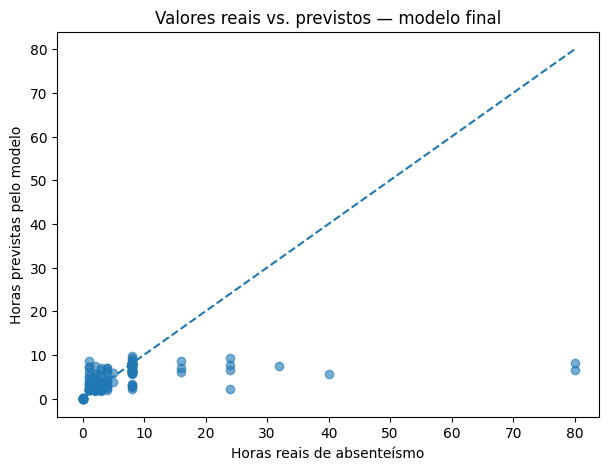

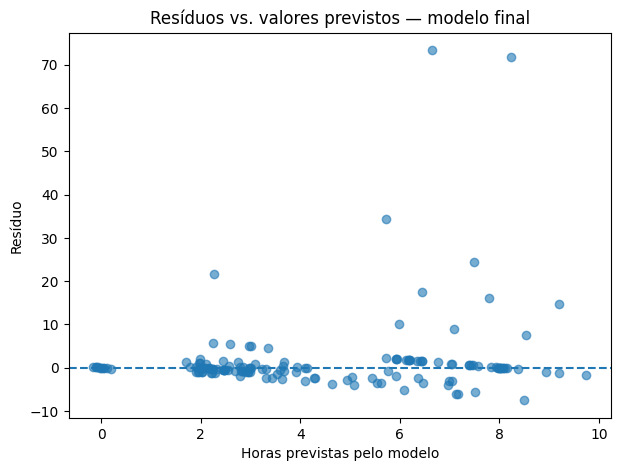

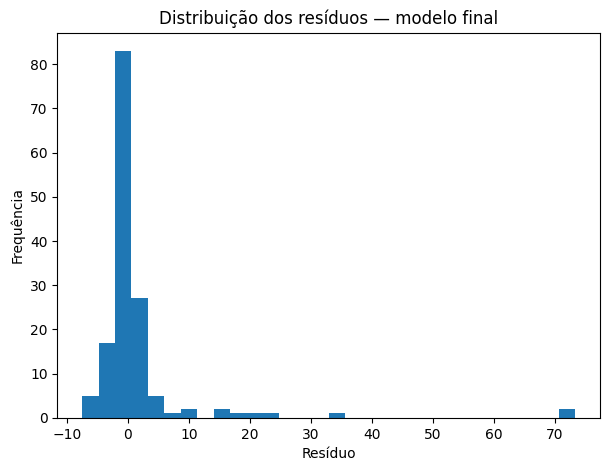

In [ ]:
# === Avaliação final no conjunto de teste ===

# Garante que o modelo otimizado da seção 9 será usado
final_model = best_model
final_model_name = "GradientBoostingRegressor otimizado"

# Avalia o baseline no mesmo conjunto de teste
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

# Avalia o modelo final otimizado no conjunto de teste
y_pred_final = final_model.predict(X_test)

baseline_metrics = evaluate_regression(y_test, y_pred_baseline)
final_metrics = evaluate_regression(y_test, y_pred_final)

melhora_mae = ((baseline_metrics["MAE"] - final_metrics["MAE"]) / baseline_metrics["MAE"]) * 100

final_results = pd.DataFrame({
    "baseline": baseline_metrics,
    final_model_name: final_metrics
}).T

final_results["melhora_MAE_vs_baseline_%"] = [0, melhora_mae]

final_results = final_results.round({
    "MAE": 2,
    "RMSE": 2,
    "R2": 3,
    "melhora_MAE_vs_baseline_%": 2
})

print("Modelo final:", final_model_name)
print("Melhora do MAE em relação ao baseline:", round(melhora_mae, 2), "%")

display(final_results)

# Tabela auxiliar para análise dos erros
final_errors = pd.DataFrame({
    "valor_real": np.array(y_test),
    "valor_previsto": y_pred_final,
    "residuo": np.array(y_test) - y_pred_final,
    "erro_absoluto": np.abs(np.array(y_test) - y_pred_final)
})

print("\nResumo dos erros absolutos do modelo final:")

resumo_erros = (
    final_errors["erro_absoluto"]
    .describe()
    .rename(index={
        "count": "quantidade",
        "mean": "média",
        "std": "desvio padrão",
        "min": "mínimo",
        "25%": "1º quartil",
        "50%": "mediana",
        "75%": "3º quartil",
        "max": "máximo"
    })
    .to_frame("valor")
    .round(2)
)

display(resumo_erros)

# Gráfico: valores reais vs. valores previstos
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_final, alpha=0.6)

min_value = min(np.min(y_test), np.min(y_pred_final))
max_value = max(np.max(y_test), np.max(y_pred_final))

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.title("Valores reais vs. previstos — modelo final")
plt.xlabel("Horas reais de absenteísmo")
plt.ylabel("Horas previstas pelo modelo")
plt.show()

# Gráfico: resíduos vs. valores previstos
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_final, final_errors["residuo"], alpha=0.6)
plt.axhline(0, linestyle="--")
plt.title("Resíduos vs. valores previstos — modelo final")
plt.xlabel("Horas previstas pelo modelo")
plt.ylabel("Resíduo")
plt.show()

# Gráfico: distribuição dos resíduos
plt.figure(figsize=(7, 5))
plt.hist(final_errors["residuo"], bins=30)
plt.title("Distribuição dos resíduos — modelo final")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.show()

## 10.1 Análise de erros e limitações

A avaliação final mostrou que o GradientBoostingRegressor otimizado superou o baseline no conjunto de teste. O MAE foi reduzido de 4,53 para 3,29 horas, representando melhora de 27,34% em relação ao modelo de referência. Esse resultado atende ao critério de sucesso definido no início do MVP, que previa redução mínima de 10% em relação ao baseline.

Além do MAE, as métricas complementares também indicaram melhora. O RMSE passou de 10,91 no baseline para 9,86 no modelo final, sugerindo redução no impacto dos erros maiores. O R² passou de -0,092 para 0,108, indicando que o modelo final explica melhor a variação da variável-alvo do que o baseline, embora o valor ainda seja baixo.

A análise dos gráficos mostra que o modelo apresenta melhor desempenho em ocorrências de curta duração, que são mais frequentes na base. No gráfico de valores reais vs. previstos, a maior parte dos pontos está concentrada em valores baixos, coerente com a distribuição observada na análise exploratória. No entanto, alguns registros reais de maior duração aparecem distantes da linha ideal, indicando que o modelo tende a subestimar ausências muito longas.

O gráfico de resíduos vs. valores previstos reforça essa limitação. A maior parte dos resíduos está próxima de zero, indicando erros menores em muitos casos, mas existem resíduos positivos elevados. Como o resíduo foi calculado como valor real menos valor previsto, esses casos representam situações em que o modelo previu menos horas do que o valor realmente observado.

A distribuição dos resíduos também mostra concentração próxima de zero, mas com uma cauda positiva associada a erros maiores em ocorrências extremas. Esse comportamento é coerente com a própria estrutura da variável-alvo, que possui muitos registros de baixa duração e poucos casos de absenteísmo muito elevado.

Portanto, o modelo final é útil como uma solução inicial para apoiar análises gerenciais de RH e estimar a duração provável de ocorrências de absenteísmo. Porém, ele deve ser interpretado com cautela em casos extremos e não deve ser utilizado para decisões individuais, automáticas ou punitivas. A solução é mais adequada para análises agregadas, planejamento operacional e apoio exploratório à gestão.

# 11. Comparação final dos modelos

A tabela abaixo apresenta uma síntese comparativa dos modelos avaliados no MVP. A métrica principal utilizada para comparação é o MAE, pois indica diretamente o erro médio em horas de absenteísmo. As métricas RMSE e R² são usadas como apoio para interpretar erros maiores e capacidade geral de explicação da variável-alvo.

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | MAE = 4,53 | RMSE = 10,91; R² = -0,092 | 0,020 s | Referência mínima; prevê valor constante pela mediana. |
| LinearRegression | MAE = 5,70 | RMSE = 10,48; R² = -0,008 | 0,019 s | Modelo simples e interpretável, mas não superou o baseline. |
| RandomForestRegressor | MAE = 4,92 | RMSE = 11,22; R² = -0,155 | 0,810 s | Modelo não linear, mas teve desempenho inferior ao baseline. |
| GradientBoostingRegressor | MAE = 3,32 | RMSE = 9,92; R² = 0,098 | 0,365 s | Melhor modelo na avaliação inicial. |
| GradientBoostingRegressor otimizado | MAE = 3,29 | RMSE = 9,86; R² = 0,108 | Otimização com 40 ajustes | Modelo final escolhido; reduziu o MAE em 27,34% em relação ao baseline. |

A comparação final indica que o GradientBoostingRegressor otimizado foi o modelo mais adequado para o MVP no conjunto de teste. Ele apresentou o menor MAE, menor RMSE e melhor R² entre os modelos avaliados. Além disso, superou o baseline em mais de 10%, atendendo ao critério de sucesso definido no início do projeto.

# 12. Boas práticas e rastreabilidade

Esta seção registra as principais decisões tomadas ao longo do desenvolvimento do MVP, com o objetivo de tornar o processo mais transparente, reprodutível e rastreável.

Foi utilizada seed fixa igual a 42 nas etapas que envolvem aleatoriedade, como divisão treino/teste, validação cruzada e modelos com componentes aleatórios. O projeto foi executado em ambiente Google Colab, com carregamento dos dados diretamente a partir de URL pública no GitHub, evitando dependência de arquivos locais.

As principais decisões do projeto estão resumidas na tabela abaixo.

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Usar seed fixa igual a 42 | Garantir maior reprodutibilidade nas etapas com aleatoriedade | Permitir que os resultados sejam reproduzidos de forma mais consistente |
| Carregar o dataset por URL pública do GitHub | Evitar dependência de upload manual no Colab | Facilitar a execução do notebook pelo avaliador |
| Definir Absenteeism time in hours como variável-alvo | A variável representa a duração do absenteísmo em horas, coerente com o objetivo do MVP | Permitir tratar o problema como regressão supervisionada |
| Remover a coluna ID das variáveis explicativas | A coluna representa identificação do colaborador e poderia induzir aprendizado associado a indivíduos específicos | Reduzir risco de vazamento e melhorar a generalização |
| Separar treino e teste antes do pré-processamento | Evitar que informações do conjunto de teste influenciem as transformações aplicadas ao treino | Reduzir vazamento de dados |
| Usar holdout 80/20 para treino e teste | A base possui 740 registros, permitindo separar uma parte para avaliação final | Manter um conjunto de teste independente para avaliação do modelo |
| Tratar variáveis codificadas como categorias quando aplicável | Algumas colunas numéricas representam categorias, como motivo, mês, dia da semana, estação e escolaridade | Evitar interpretação equivocada de códigos como valores contínuos |
| Usar imputação por mediana nas variáveis numéricas | A mediana é menos sensível a valores extremos | Tornar o pré-processamento mais robusto |
| Usar imputação pela categoria mais frequente nas variáveis categóricas | Estratégia simples e adequada para variáveis categóricas | Permitir tratamento reprodutível caso apareçam valores ausentes |
| Aplicar One-Hot Encoding nas variáveis categóricas | Evitar que o modelo interprete categorias codificadas como ordem matemática | Representar corretamente categorias no modelo |
| Aplicar StandardScaler às variáveis numéricas | As variáveis possuem escalas diferentes | Beneficiar modelos sensíveis à escala e manter pipeline padronizado |
| Usar DummyRegressor como baseline | Criar uma referência mínima de desempenho baseada na mediana | Verificar se os modelos realmente aprendem padrões úteis |
| Testar LinearRegression, RandomForestRegressor e GradientBoostingRegressor | Comparar abordagem linear simples com modelos não lineares baseados em árvores | Avaliar se maior flexibilidade melhora a previsão |
| Usar MAE como métrica principal | O MAE é interpretável diretamente em horas de absenteísmo | Facilitar a leitura prática do erro médio |
| Usar RMSE e R² como métricas complementares | RMSE penaliza erros maiores e R² indica capacidade de explicação da variável-alvo | Ampliar a análise do desempenho dos modelos |
| Registrar tempo aproximado de treino | Acompanhar o custo computacional dos modelos avaliados | Demonstrar que os modelos são compatíveis com o escopo do MVP |
| Otimizar o GradientBoostingRegressor | Foi o modelo com melhor desempenho na avaliação inicial | Buscar melhora adicional no modelo final |
| Usar RandomizedSearchCV com KFold de 5 divisões | Realizar busca simples de hiperparâmetros sem custo computacional excessivo | Escolher hiperparâmetros de forma mais robusta |
| Limitar a busca a 8 combinações de hiperparâmetros | Manter o escopo compatível com um MVP e com o tamanho da base | Reduzir tempo de execução sem abandonar a otimização |
| Não utilizar deep learning | A base é tabular, pequena e compatível com modelos clássicos de Machine Learning | Evitar complexidade desnecessária |
| Interpretar os resultados como apoio gerencial | A base possui limitações, valores extremos e dados potencialmente sensíveis | Evitar uso para decisões individuais, automáticas ou punitivas |

# 13. Conclusão

O objetivo deste MVP foi construir e avaliar modelos de Machine Learning para prever a duração de ocorrências de absenteísmo no trabalho, medida em horas, a partir das características registradas no dataset Absenteeism at work.

A melhor solução encontrada foi o GradientBoostingRegressor otimizado. No conjunto de teste, esse modelo apresentou MAE de 3,29 horas, enquanto o baseline DummyRegressor apresentou MAE de 4,53 horas. Isso representa uma melhora de 27,34% em relação ao modelo de referência, superando o critério de sucesso definido no início do projeto, que era obter redução mínima de 10% no MAE.

Além do MAE, as métricas complementares também indicaram melhora do modelo final em relação ao baseline. O RMSE foi reduzido de 10,91 para 9,86, sugerindo menor impacto dos erros maiores. O R² passou de -0,092 para 0,108, mostrando que o modelo final apresentou maior capacidade de explicação da variável-alvo, embora ainda limitada.

O principal aprendizado do projeto foi que a duração do absenteísmo apresenta distribuição assimétrica, com grande concentração de ocorrências curtas e poucos casos de duração muito elevada. Essa característica influenciou diretamente o desempenho dos modelos. O modelo final conseguiu melhorar a previsão média em relação ao baseline, mas ainda apresentou dificuldade para prever ausências muito longas, tendendo a subestimar esses casos extremos.

Como limitação, os resultados devem ser interpretados com cautela, pois a base representa uma empresa específica, em um período histórico delimitado, e contém variáveis potencialmente sensíveis no contexto de gestão de pessoas. Assim, o modelo não deve ser utilizado para decisões individuais, automáticas ou punitivas. Seu uso mais adequado é como apoio exploratório e gerencial, contribuindo para análises agregadas de RH, planejamento operacional e discussões sobre saúde ocupacional.

Como próximos passos, recomenda-se testar o modelo com dados mais recentes e de outras organizações, avaliar estratégias específicas para lidar com valores extremos, explorar novas variáveis explicativas e acompanhar o desempenho do modelo em cenários reais de uso. Também seria possível testar transformações na variável-alvo ou abordagens específicas para diferenciar ausências curtas e longas.

# 14. Salvamento de artefatos

Nesta seção, serão salvos artefatos gerados pelo próprio notebook, como o modelo final treinado e as tabelas de resultados. O salvamento é opcional, mas contribui para a rastreabilidade do MVP e permitiria reutilizar o pipeline final sem repetir todo o treinamento.

Os arquivos salvos não são necessários para a execução do notebook do início ao fim, pois todo o processo de carregamento dos dados, pré-processamento, treinamento e avaliação permanece reprodutível diretamente no Google Colab. Caso necessário, esses artefatos podem ser baixados ou reutilizados posteriormente a partir do ambiente de execução.

In [ ]:
# === Salvamento de artefatos ===

import joblib

if final_model is not None:
    joblib.dump(final_model, "modelo_final.pkl")
    print("Modelo final salvo como modelo_final.pkl")

if "results_initial" in globals():
    results_initial.to_csv("resultados_avaliacao_inicial.csv")
    print("Tabela de avaliação inicial salva como resultados_avaliacao_inicial.csv")

if "final_results" in globals():
    final_results.to_csv("resultados_avaliacao_final.csv")
    print("Tabela de avaliação final salva como resultados_avaliacao_final.csv")

Modelo final salvo como modelo_final.pkl
Tabela de avaliação inicial salva como resultados_avaliacao_inicial.csv
Tabela de avaliação final salva como resultados_avaliacao_final.csv
